# 09 — TKG & T-Logic Visualization

Four figures for UseCase 4 (EPC compliance, TR Meram dataset):

| Figure | Content |
|--------|---------|
| **Fig 1** | TKG schema — entity types, relation types, which edges carry bitemporal timestamps |
| **Fig 2** | Instance subgraph — 3 real workers, hot_work permit, certifications, PERMIT_DENIED |
| **Fig 3** | Bitemporal semantics — valid-time x transaction-time + worker compliance timeline |
| **Fig 4** | T-Logic rules — R1 MissingCert and R2 PostRuleChange as graph-path diagrams |

PNGs saved to `experiments/UseCase4/results/`.

## 0. Setup & Data

In [1]:
"""Redesigned TKG + T-Logic visualizations — fully manual layout, no overlaps."""
import json
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
from matplotlib.lines import Line2D
from pathlib import Path

DATA_DIR = Path("../../data/UseCase4")
OUT_DIR  = Path("../../experiments/UseCase4/results")

d  = json.load(open(DATA_DIR / "epc_dataset_real.json", encoding="utf-8"))
ev = json.load(open(DATA_DIR / "epc_events.json",       encoding="utf-8"))

workers  = {w["id"]: w for w in d["workers"]}
denied   = ev["permit_denied"]

CERT_REQS_PRE  = {"Hot_Work_Safety", "Fire_Watch", "Welding_Certification"}
CERT_REQS_POST = CERT_REQS_PRE | {"Advanced_Fire_Watch"}

BG   = "#111318"
CARD = "#1c2130"

# ── helpers ──────────────────────────────────────────────────────────────────
def box(ax, cx, cy, w, h, label, facecolor, edgecolor,
        fontsize=10, lw=1.8, sublabel=None):
    """Draw a rounded rectangle node centred at (cx, cy)."""
    p = FancyBboxPatch((cx - w/2, cy - h/2), w, h,
                       boxstyle="round,pad=0.06", lw=lw,
                       facecolor=facecolor, edgecolor=edgecolor, zorder=3)
    ax.add_patch(p)
    if sublabel:
        ax.text(cx, cy + 0.10, label, ha="center", va="center",
                fontsize=fontsize, fontweight="bold", color="white", zorder=4)
        ax.text(cx, cy - 0.22, sublabel, ha="center", va="center",
                fontsize=6.5, color="#90CAF9", zorder=4)
    else:
        ax.text(cx, cy, label, ha="center", va="center",
                fontsize=fontsize, fontweight="bold", color="white", zorder=4)

def arrow(ax, x1, y1, x2, y2, label="", color="#90CAF9", lw=1.5,
          ls="-", rad=0.0, label_offset=(0, 0.18), fontsize=8):
    """Draw an annotated arrow."""
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="-|>", color=color, lw=lw,
                                linestyle=ls,
                                connectionstyle=f"arc3,rad={rad}"),
                zorder=2)
    if label:
        mx = (x1 + x2) / 2 + label_offset[0]
        my = (y1 + y2) / 2 + label_offset[1]
        ax.text(mx, my, label, ha="center", va="bottom",
                fontsize=fontsize, color=color,
                bbox=dict(boxstyle="round,pad=0.15", fc=BG, ec="none"), zorder=5)

def setup_ax(ax, xlim, ylim):
    ax.set_xlim(*xlim); ax.set_ylim(*ylim)
    ax.axis("off"); ax.set_facecolor(BG)

## Fig 1 — TKG Schema (ontology level)

**Entity types** (nodes) and **relation types** (edges) in the EPC TKG. Top row: the workflow hierarchy Worker → Step → Activity → Family. Bottom row: the certification compliance chain Step → WorkPermit → Certification.

- **Solid** edges: static (no temporal attributes)
- **Dashed** edges: bitemporally versioned — carry `valid_from` / `valid_to` (when the fact is true in the real world) and `tx_time` (when it was written to the DB)

Saved viz_tkg_schema.png


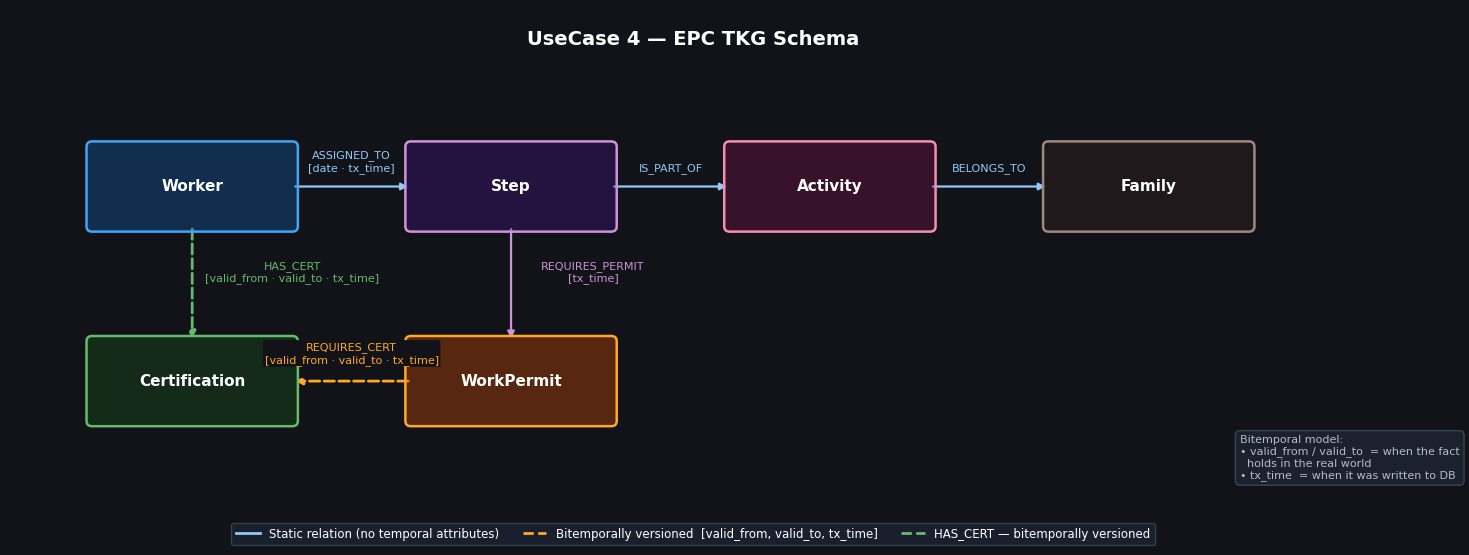

In [2]:
# FIG 1 — TKG SCHEMA
# Clean L-shaped layout: top row = workflow hierarchy, bottom row = cert chain
# ═════════════════════════════════════════════════════════════════════════════
fig1, ax = plt.subplots(figsize=(15, 6))
fig1.patch.set_facecolor(BG)
setup_ax(ax, (0, 15), (0, 6))

# Node colors
NC = {"Worker":      ("#1565C0", "#42A5F5"),
      "Certification":("#1B5E20", "#66BB6A"),
      "WorkPermit":  ("#E65100", "#FFA726"),
      "Step":        ("#4A148C", "#CE93D8"),
      "Activity":    ("#880E4F", "#F48FB1"),
      "Family":      ("#3E2723", "#A1887F")}

# Positions (cx, cy) — top row y=4, bottom row y=2
NP = {"Worker":      (2,   4.0),
      "Step":        (5.5, 4.0),
      "Activity":    (9.0, 4.0),
      "Family":      (12.5,4.0),
      "WorkPermit":  (5.5, 1.8),
      "Certification":(2,  1.8)}

NW, NH = 2.2, 0.9

for name, (cx, cy) in NP.items():
    fc, ec = NC[name]
    box(ax, cx, cy, NW, NH, name, fc + "55", ec, fontsize=11)

# ── TOP ROW: horizontal workflow chain ───────────────────────────────────────
arrow(ax, 3.1, 4.0, 4.4, 4.0,
      "ASSIGNED_TO\n[date · tx_time]", "#90CAF9", lw=1.6, label_offset=(0, 0.15))
arrow(ax, 6.6, 4.0, 7.9, 4.0,
      "IS_PART_OF", "#90CAF9", lw=1.6, label_offset=(0, 0.15))
arrow(ax, 10.1, 4.0, 11.4, 4.0,
      "BELONGS_TO", "#90CAF9", lw=1.6, label_offset=(0, 0.15))

# ── VERTICAL: Step → WorkPermit ──────────────────────────────────────────────
arrow(ax, 5.5, 3.55, 5.5, 2.25,
      "REQUIRES_PERMIT\n[tx_time]", "#CE93D8", lw=1.6, label_offset=(0.9, 0))

# ── BOTTOM ROW: WorkPermit → Certification (bitemporally versioned) ───────────
arrow(ax, 4.4, 1.8, 3.1, 1.8,
      "REQUIRES_CERT\n[valid_from · valid_to · tx_time]",
      "#FFA726", lw=2.0, ls="--", label_offset=(0, 0.18))

# ── VERTICAL: Worker → Certification (bitemporally versioned) ─────────────────
arrow(ax, 2.0, 3.55, 2.0, 2.25,
      "HAS_CERT\n[valid_from · valid_to · tx_time]",
      "#66BB6A", lw=2.0, ls="--", label_offset=(1.1, 0))

# ── Title & legend ────────────────────────────────────────────────────────────
ax.text(7.5, 5.6, "UseCase 4 — EPC TKG Schema",
        ha="center", fontsize=14, fontweight="bold", color="white")

legend_items = [
    Line2D([0], [0], color="#90CAF9", lw=2,   ls="-",  label="Static relation (no temporal attributes)"),
    Line2D([0], [0], color="#FFA726", lw=2,   ls="--", label="Bitemporally versioned  [valid_from, valid_to, tx_time]"),
    Line2D([0], [0], color="#66BB6A", lw=2,   ls="--", label="HAS_CERT — bitemporally versioned"),
]
ax.legend(handles=legend_items, loc="lower center", ncol=3,
          fontsize=8.5, facecolor=CARD, labelcolor="white",
          framealpha=0.9, edgecolor="#37474F",
          bbox_to_anchor=(0.5, -0.02))

# Bitemporal annotation box (bottom right)
ax.text(13.5, 1.2,
        "Bitemporal model:\n"
        "• valid_from / valid_to  = when the fact\n"
        "  holds in the real world\n"
        "• tx_time  = when it was written to DB",
        ha="left", va="top", fontsize=8, color="#B0BEC5",
        bbox=dict(boxstyle="round,pad=0.4", fc=CARD, ec="#37474F", lw=1))

fig1.tight_layout(rect=[0, 0.06, 1, 1])
fig1.savefig(OUT_DIR / "viz_tkg_schema.png", dpi=160, bbox_inches="tight",
             facecolor=BG)
print("Saved viz_tkg_schema.png")

## Fig 2 — Instance Subgraph: 3 workers x hot_work permit

Instance subgraph from the real dataset. Three workers interact with the `hot_work` WorkPermit through a Step node. A rule change on 2024-06-29 added a new certification requirement (Advanced Fire Watch).

- **W-001**: did not hold the new cert → PERMIT_DENIED after rule change
- **W-007, W-023**: already held all 4 certs → remain qualified
- Yellow dashed: `REQUIRES_CERT` pre-rule (valid_to = 2024-06-28)
- Orange dashed: `REQUIRES_CERT` post-rule (valid_from = 2024-06-29)

Saved viz_tkg_instance.png


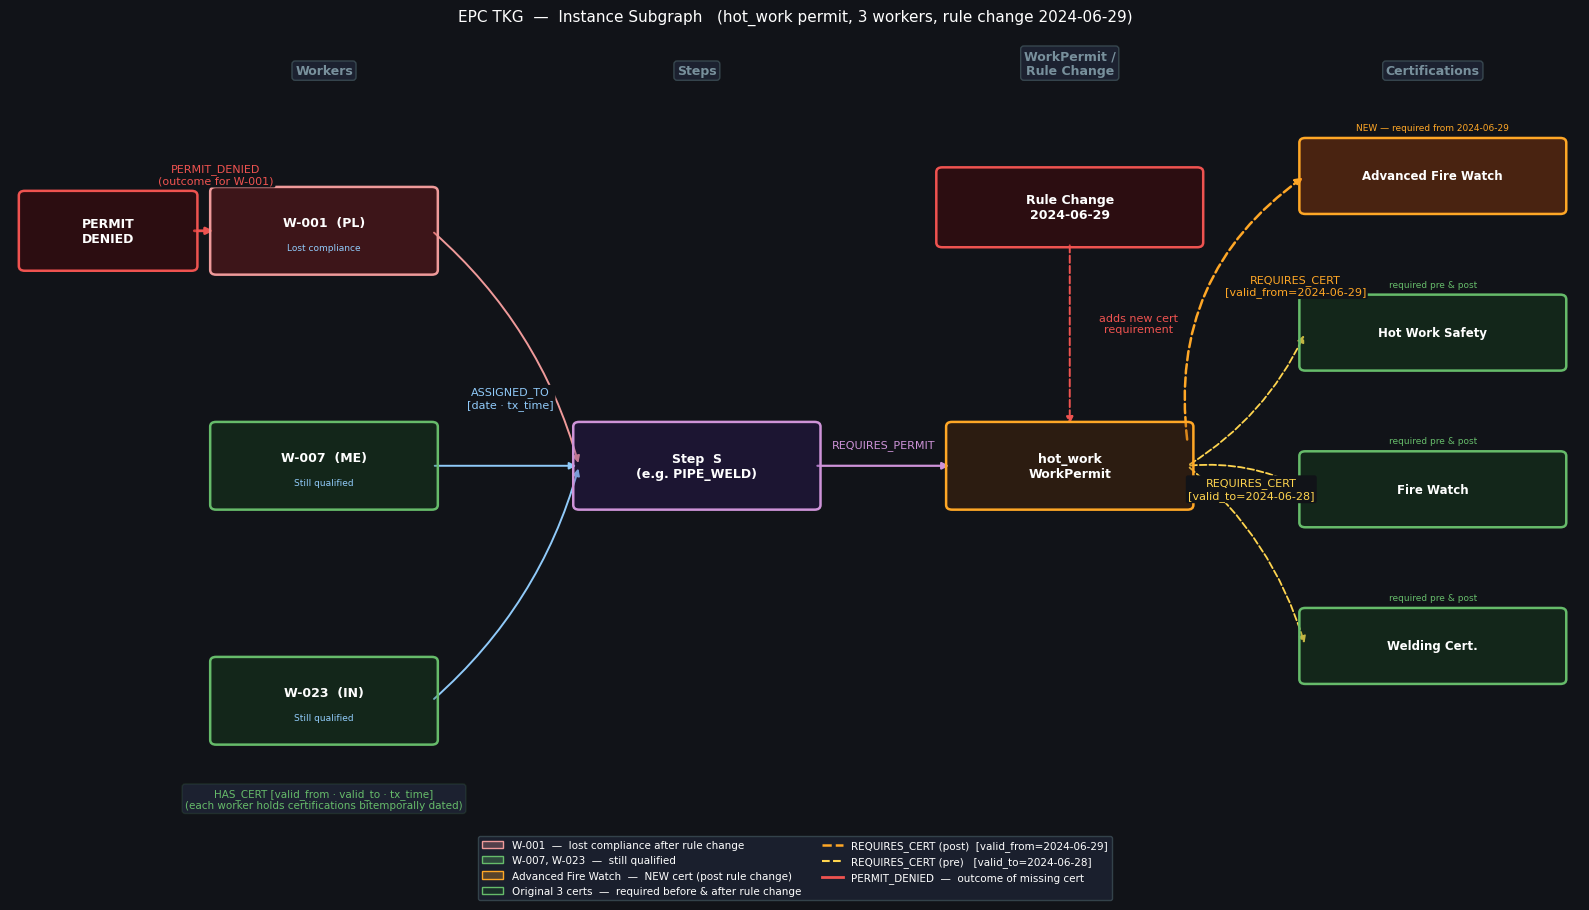

In [3]:
# FIG 2 — INSTANCE SUBGRAPH
# 4-column layout:
#   Col A (x=1.5)  : PERMIT_DENIED
#   Col B (x=3.8)  : Workers (3 rows)
#   Col C (x=7.5)  : Step  |  WorkPermit (same x, different y)
#   Col D (x=12.5) : Certs (4 stacked vertically)
# Rule-change event sits above WorkPermit at col C
# ═════════════════════════════════════════════════════════════════════════════
fig2, ax = plt.subplots(figsize=(16, 10))
fig2.patch.set_facecolor(BG)
setup_ax(ax, (0, 16), (0, 11))

# Column x-positions
XW  = 3.2    # Workers
XS  = 7.0    # Step
XP  = 10.8   # WorkPermit / Rule Change
XC  = 14.5   # Certifications
XD  = 1.0    # PERMIT_DENIED

# Row y-positions
W1_Y, W2_Y, W3_Y = 8.5, 5.5, 2.5   # three workers (well separated)
STEP_Y   = 5.5
PERMIT_Y = 5.5
RC_Y     = 8.8
CERT_Y   = [9.2, 7.2, 5.2, 3.2]     # [new cert TOP, then 3 pre-certs below]

# ── Workers ───────────────────────────────────────────────────────────────────
box(ax, XW, W1_Y, 2.2, 1.0, "W-001  (PL)", "#B71C1C44", "#EF9A9A", fontsize=9,
    sublabel="Lost compliance")
box(ax, XW, W2_Y, 2.2, 1.0, "W-007  (ME)", "#1B5E2044", "#66BB6A", fontsize=9,
    sublabel="Still qualified")
box(ax, XW, W3_Y, 2.2, 1.0, "W-023  (IN)", "#1B5E2044", "#66BB6A", fontsize=9,
    sublabel="Still qualified")

# ── HAS_CERT label (annotation, not node) ─────────────────────────────────────
ax.text(XW, 1.1,
        "HAS_CERT [valid_from · valid_to · tx_time]\n"
        "(each worker holds certifications bitemporally dated)",
        ha="center", va="bottom", fontsize=7.5, color="#66BB6A",
        bbox=dict(boxstyle="round,pad=0.3", fc=CARD, ec="#66BB6A22", lw=1))

# ── Step ──────────────────────────────────────────────────────────────────────
box(ax, XS, STEP_Y, 2.4, 1.0, "Step  S\n(e.g. PIPE_WELD)", "#3D1C7A44", "#CE93D8", fontsize=9)

# ── WorkPermit ────────────────────────────────────────────────────────────────
box(ax, XP, PERMIT_Y, 2.4, 1.0, "hot_work\nWorkPermit", "#7A350044", "#FFA726", fontsize=9)

# ── Rule-change event ─────────────────────────────────────────────────────────
box(ax, XP, RC_Y, 2.6, 0.9, "Rule Change\n2024-06-29", "#7A000044", "#EF5350", fontsize=9)

# ── Certifications — 4 boxes stacked, clearly labelled ───────────────────────
CERT_LABELS = [
    ("Advanced Fire Watch", "#FFA726", "#E6510044", "NEW — required from 2024-06-29"),
    ("Hot Work Safety",     "#66BB6A", "#1B5E2044", "required pre & post"),
    ("Fire Watch",          "#66BB6A", "#1B5E2044", "required pre & post"),
    ("Welding Cert.",       "#66BB6A", "#1B5E2044", "required pre & post"),
]
for (lbl, ec, fc, note), cy in zip(CERT_LABELS, CERT_Y):
    box(ax, XC, cy, 2.6, 0.85, lbl, fc, ec, fontsize=8.5)
    ax.text(XC, cy + 0.56, note, ha="center", va="bottom",
            fontsize=6.5, color=ec,
            bbox=dict(boxstyle="round,pad=0.08", fc=BG, ec="none"))

# ── PERMIT_DENIED ──────────────────────────────────────────────────────────────
box(ax, XD, W1_Y, 1.7, 0.9, "PERMIT\nDENIED", "#7A000044", "#EF5350", fontsize=9)

# ══ ARROWS ════════════════════════════════════════════════════════════════════

# W-001 → Step  (red dashed — involves a violation)
arrow(ax, XW+1.1, W1_Y, XS-1.2, STEP_Y, color="#EF9A9A", lw=1.4, rad=-0.15)
# W-007 → Step  (straight)
arrow(ax, XW+1.1, W2_Y, XS-1.2, STEP_Y, color="#90CAF9", lw=1.4, rad=0.0)
# W-023 → Step  (blue arc)
arrow(ax, XW+1.1, W3_Y, XS-1.2, STEP_Y, color="#90CAF9", lw=1.4, rad=0.15)
# shared label
ax.text((XW+XS)/2, STEP_Y + 0.75, "ASSIGNED_TO\n[date · tx_time]",
        ha="center", fontsize=8, color="#90CAF9",
        bbox=dict(boxstyle="round,pad=0.15", fc=BG, ec="none"))

# Step → WorkPermit
arrow(ax, XS+1.2, STEP_Y, XP-1.2, PERMIT_Y,
      "REQUIRES_PERMIT", "#CE93D8", lw=1.6, label_offset=(0, 0.2))

# Rule Change → WorkPermit  (vertical, dashed red)
arrow(ax, XP, RC_Y-0.45, XP, PERMIT_Y+0.5,
      "adds new cert\nrequirement", "#EF5350", lw=1.4, ls="--", label_offset=(0.7, 0))

# WorkPermit → NEW cert  (orange dashed, upward arc)
arrow(ax, XP+1.2, PERMIT_Y+0.3, XC-1.3, CERT_Y[0],
      "REQUIRES_CERT\n[valid_from=2024-06-29]",
      "#FFA726", lw=1.8, ls="--", rad=-0.3, label_offset=(0.5, 0.15))

# WorkPermit → 3 pre-rule certs  (yellow dashed)
# Draw a single "fork" line from permit to the three certs
for cy in CERT_Y[1:]:
    r = 0.15 * (cy - PERMIT_Y) / abs(cy - PERMIT_Y + 0.001)
    arrow(ax, XP+1.2, PERMIT_Y, XC-1.3, cy, color="#FFD54F", lw=1.3, ls="--", rad=r)
# One shared label in the middle of the three certs
ax.text((XP+XC)/2, CERT_Y[2], "REQUIRES_CERT\n[valid_to=2024-06-28]",
        ha="center", va="center", fontsize=8, color="#FFD54F",
        bbox=dict(boxstyle="round,pad=0.2", fc=BG, ec="none"))

# PERMIT_DENIED → W-001  (outcome arrow)
arrow(ax, XD+0.85, W1_Y, XW-1.1, W1_Y,
      "", "#EF5350", lw=2.0)
ax.text((XD+XW)/2, W1_Y + 0.6, "PERMIT_DENIED\n(outcome for W-001)",
        ha="center", fontsize=8, color="#EF5350",
        bbox=dict(boxstyle="round,pad=0.15", fc=BG, ec="none"))

# ── Column headers ────────────────────────────────────────────────────────────
for x, lbl in [(XW, "Workers"), (XS, "Steps"),
               (XP, "WorkPermit /\nRule Change"), (XC, "Certifications")]:
    ax.text(x, 10.5, lbl, ha="center", fontsize=9, color="#78909C", fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.25", fc=CARD, ec="#37474F"))

# ── Legend ────────────────────────────────────────────────────────────────────
leg = [
    mpatches.Patch(fc="#EF9A9A44", ec="#EF9A9A", label="W-001  —  lost compliance after rule change"),
    mpatches.Patch(fc="#66BB6A44", ec="#66BB6A", label="W-007, W-023  —  still qualified"),
    mpatches.Patch(fc="#FFA72644", ec="#FFA726", label="Advanced Fire Watch  —  NEW cert (post rule change)"),
    mpatches.Patch(fc="#1B5E2044", ec="#66BB6A", label="Original 3 certs  —  required before & after rule change"),
    Line2D([0],[0], color="#FFA726", ls="--", lw=1.8, label="REQUIRES_CERT (post)  [valid_from=2024-06-29]"),
    Line2D([0],[0], color="#FFD54F", ls="--", lw=1.5, label="REQUIRES_CERT (pre)   [valid_to=2024-06-28]"),
    Line2D([0],[0], color="#EF5350", ls="-",  lw=2.0, label="PERMIT_DENIED  —  outcome of missing cert"),
]
ax.legend(handles=leg, loc="lower center", ncol=2, fontsize=7.5, facecolor=CARD,
          labelcolor="white", framealpha=0.9, edgecolor="#37474F",
          bbox_to_anchor=(0.5, -0.01))

ax.set_title("EPC TKG  —  Instance Subgraph   (hot_work permit, 3 workers, rule change 2024-06-29)",
             color="white", fontsize=11, pad=10)

fig2.tight_layout(rect=[0, 0.08, 1, 1])
fig2.savefig(OUT_DIR / "viz_tkg_instance.png", dpi=160, bbox_inches="tight",
             facecolor=BG)
print("Saved viz_tkg_instance.png")

## Fig 3 — Bitemporal Semantics

**Left:** 2D bitemporal rectangle diagram for `REQUIRES_CERT (hot_work)`. X-axis = **valid time** (when the rule is in force in the real world). Y-axis = **transaction time** (when the fact was recorded in the database). Two rectangle versions coexist in the DB — the pre-rule and the post-rule — each with different valid-time intervals.

**Right:** per-worker compliance Gantt chart. W-001 and W-002 are compliant before the rule change but become non-compliant after 2024-06-29 because they lack Advanced Fire Watch certification.

Saved viz_bitemporal.png


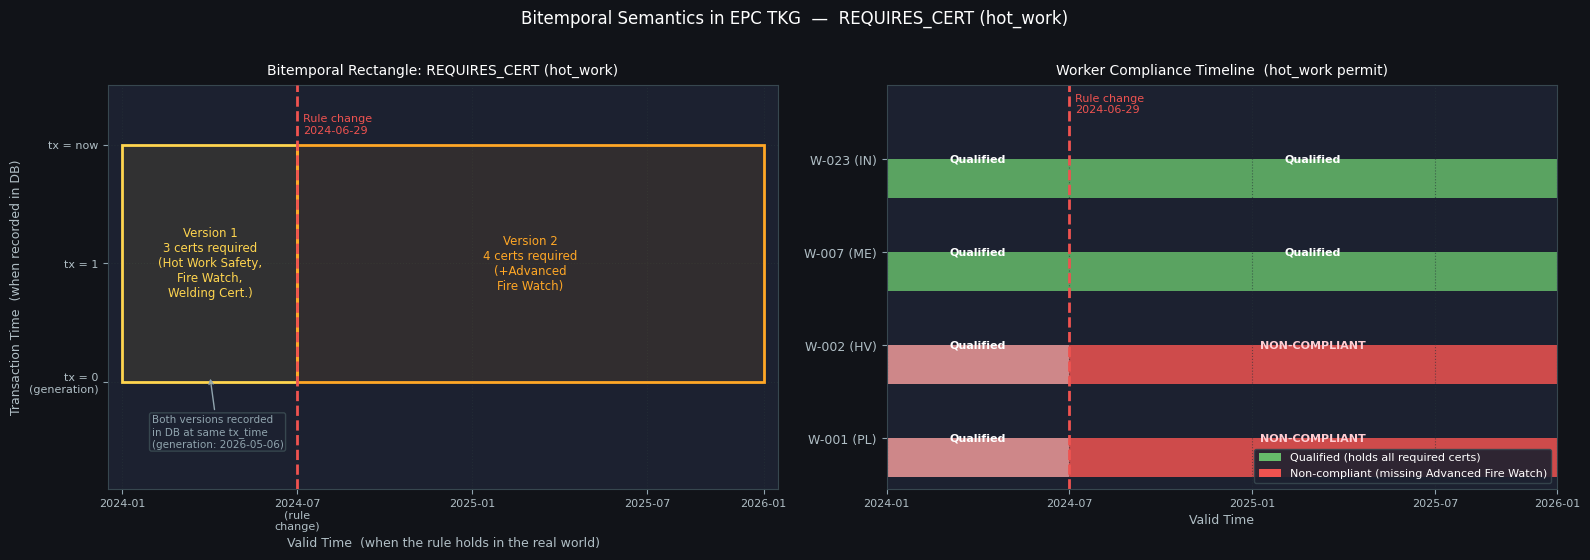

In [4]:
# FIG 3 — BITEMPORAL SEMANTICS
# Left: two-axis (VT × TT) bitemporal space
# Right: worker compliance Gantt chart
# ═════════════════════════════════════════════════════════════════════════════
fig3, (axL, axR) = plt.subplots(1, 2, figsize=(16, 5.5))
fig3.patch.set_facecolor(BG)
for a in (axL, axR):
    a.set_facecolor(CARD)
    a.tick_params(colors="#90A4AE")
    for sp in a.spines.values():
        sp.set_color("#37474F")

# ── LEFT: bitemporal rectangle diagram ────────────────────────────────────────
# X = valid time (months from 2024-01); Y = transaction time (conceptual DB version)
# Version 1: valid 0..6 months, tx 0..∞
# Version 2: valid 6..∞,  tx 0..∞
# All facts were recorded at "generation time" (tx=0), both still current (tx→∞)

VT_CHANGE = 6   # months from project start
VT_END    = 22  # show up to 22 months
TX_TOTAL  = 2   # show two conceptual DB snapshots

# Bitemporal rectangle: version 1 (pre-rule)
r1 = plt.Rectangle((0, 0), VT_CHANGE, TX_TOTAL, lw=2,
                    ec="#FFD54F", fc="#FFD54F18", zorder=2)
axL.add_patch(r1)
axL.text(VT_CHANGE/2, TX_TOTAL/2,
         "Version 1\n3 certs required\n(Hot Work Safety,\nFire Watch,\nWelding Cert.)",
         ha="center", va="center", fontsize=8.5, color="#FFD54F", zorder=3)

# Bitemporal rectangle: version 2 (post-rule)
r2 = plt.Rectangle((VT_CHANGE, 0), VT_END - VT_CHANGE, TX_TOTAL, lw=2,
                    ec="#FFA726", fc="#FFA72618", zorder=2)
axL.add_patch(r2)
axL.text(VT_CHANGE + (VT_END - VT_CHANGE)/2, TX_TOTAL/2,
         "Version 2\n4 certs required\n(+Advanced\nFire Watch)",
         ha="center", va="center", fontsize=8.5, color="#FFA726", zorder=3)

# Rule change marker
axL.axvline(VT_CHANGE, color="#EF5350", lw=2, ls="--", zorder=4)
axL.text(VT_CHANGE + 0.2, TX_TOTAL + 0.08,
         "Rule change\n2024-06-29", color="#EF5350", fontsize=8, va="bottom")

# DB facts annotation
axL.annotate("Both versions recorded\nin DB at same tx_time\n(generation: 2026-05-06)",
             xy=(VT_CHANGE/2, 0.05), xytext=(VT_CHANGE/2 - 2, -0.55),
             fontsize=7.5, color="#90A4AE",
             arrowprops=dict(arrowstyle="->", color="#90A4AE", lw=1),
             bbox=dict(boxstyle="round,pad=0.2", fc=CARD, ec="#37474F"))

axL.set_xlim(-0.5, VT_END + 0.5); axL.set_ylim(-0.9, TX_TOTAL + 0.5)
months = [0, 6, 12, 18, 22]
mlabels = ["2024-01", "2024-07\n(rule\nchange)", "2025-01", "2025-07", "2026-01"]
axL.set_xticks(months); axL.set_xticklabels(mlabels, fontsize=8, color="#B0BEC5")
axL.set_yticks([0, 1, 2])
axL.set_yticklabels(["tx = 0\n(generation)", "tx = 1", "tx = now"], fontsize=8, color="#B0BEC5")
axL.set_xlabel("Valid Time  (when the rule holds in the real world)", color="#B0BEC5", fontsize=9)
axL.set_ylabel("Transaction Time  (when recorded in DB)", color="#B0BEC5", fontsize=9)
axL.set_title("Bitemporal Rectangle: REQUIRES_CERT (hot_work)",
              color="white", fontsize=10, pad=8)
axL.grid(True, ls=":", color="#263238", alpha=0.6)

# ── RIGHT: worker compliance Gantt chart ──────────────────────────────────────
SEL_WORKERS = [
    ("W-001 (PL)", False, False),   # had 3 certs pre, missing Advanced FW post
    ("W-002 (HV)", False, False),
    ("W-007 (ME)", True,  True),    # had all 4 from the start
    ("W-023 (IN)", True,  True),
]
BAR_H = 0.5

for yi, (label, pre_ok, post_ok) in enumerate(SEL_WORKERS):
    y = yi * 1.2
    c_pre  = "#66BB6A" if pre_ok  else "#EF9A9A"
    c_post = "#66BB6A" if post_ok else "#EF5350"
    axR.barh(y, VT_CHANGE, left=0,         height=BAR_H, color=c_pre,  alpha=0.85, ec="none")
    axR.barh(y, VT_END - VT_CHANGE, left=VT_CHANGE, height=BAR_H, color=c_post, alpha=0.85, ec="none")

    s_pre  = "Qualified" if pre_ok  else "Qualified"
    s_post = "Qualified" if post_ok else "NON-COMPLIANT"
    c_lbl_post = "white" if post_ok else "#FFCDD2"
    axR.text(VT_CHANGE / 2,          y + BAR_H/2, s_pre,
             ha="center", va="center", fontsize=8, color="white", fontweight="bold")
    axR.text(VT_CHANGE + (VT_END - VT_CHANGE)/2, y + BAR_H/2, s_post,
             ha="center", va="center", fontsize=8, color=c_lbl_post, fontweight="bold")

axR.axvline(VT_CHANGE, color="#EF5350", lw=2, ls="--")
axR.text(VT_CHANGE + 0.2, len(SEL_WORKERS) * 1.2 - 0.1,
         "Rule change\n2024-06-29", color="#EF5350", fontsize=8, va="top")

axR.set_yticks([yi * 1.2 + BAR_H/2 for yi in range(len(SEL_WORKERS))])
axR.set_yticklabels([w[0] for w in SEL_WORKERS], fontsize=9, color="#B0BEC5")
axR.set_xticks([0, 6, 12, 18, 22])
axR.set_xticklabels(["2024-01", "2024-07", "2025-01", "2025-07", "2026-01"],
                     fontsize=8, color="#B0BEC5")
axR.set_xlim(0, VT_END); axR.set_ylim(-0.4, len(SEL_WORKERS) * 1.2)
axR.set_xlabel("Valid Time", color="#B0BEC5", fontsize=9)
axR.set_title("Worker Compliance Timeline  (hot_work permit)",
              color="white", fontsize=10, pad=8)
axR.grid(True, ls=":", color="#263238", alpha=0.6, axis="x")

leg3 = [mpatches.Patch(fc="#66BB6A", label="Qualified (holds all required certs)"),
        mpatches.Patch(fc="#EF5350", label="Non-compliant (missing Advanced Fire Watch)")]
axR.legend(handles=leg3, loc="lower right", fontsize=8,
           facecolor=CARD, labelcolor="white", framealpha=0.9, edgecolor="#37474F")

fig3.suptitle("Bitemporal Semantics in EPC TKG  —  REQUIRES_CERT (hot_work)",
              color="white", fontsize=12, y=1.01)
fig3.tight_layout()
fig3.savefig(OUT_DIR / "viz_bitemporal.png", dpi=160, bbox_inches="tight",
             facecolor=BG)
print("Saved viz_bitemporal.png")

## Fig 4 — T-Logic Rule Diagrams (R1 + R2)

**R1 — Missing Certification:** the body is a graph path Worker→Step→WorkPermit→Cert with temporal predicate `valid∋t`, plus the negation NOT HAS_CERT(Worker, Cert, valid∋t). If both conditions hold, the head PERMIT_DENIED fires.

**R2 — Post-Rule-Change Constraint:** same chain but the cert (Advanced Fire Watch) was introduced by the rule-change event on 2024-06-29; the rule only fires for assignments where `t > 2024-06-29`. T-Logic evaluates rules as **temporal graph walks** — each edge label carries an explicit time-interval constraint.

Saved viz_tlogic_rules.png

All done.


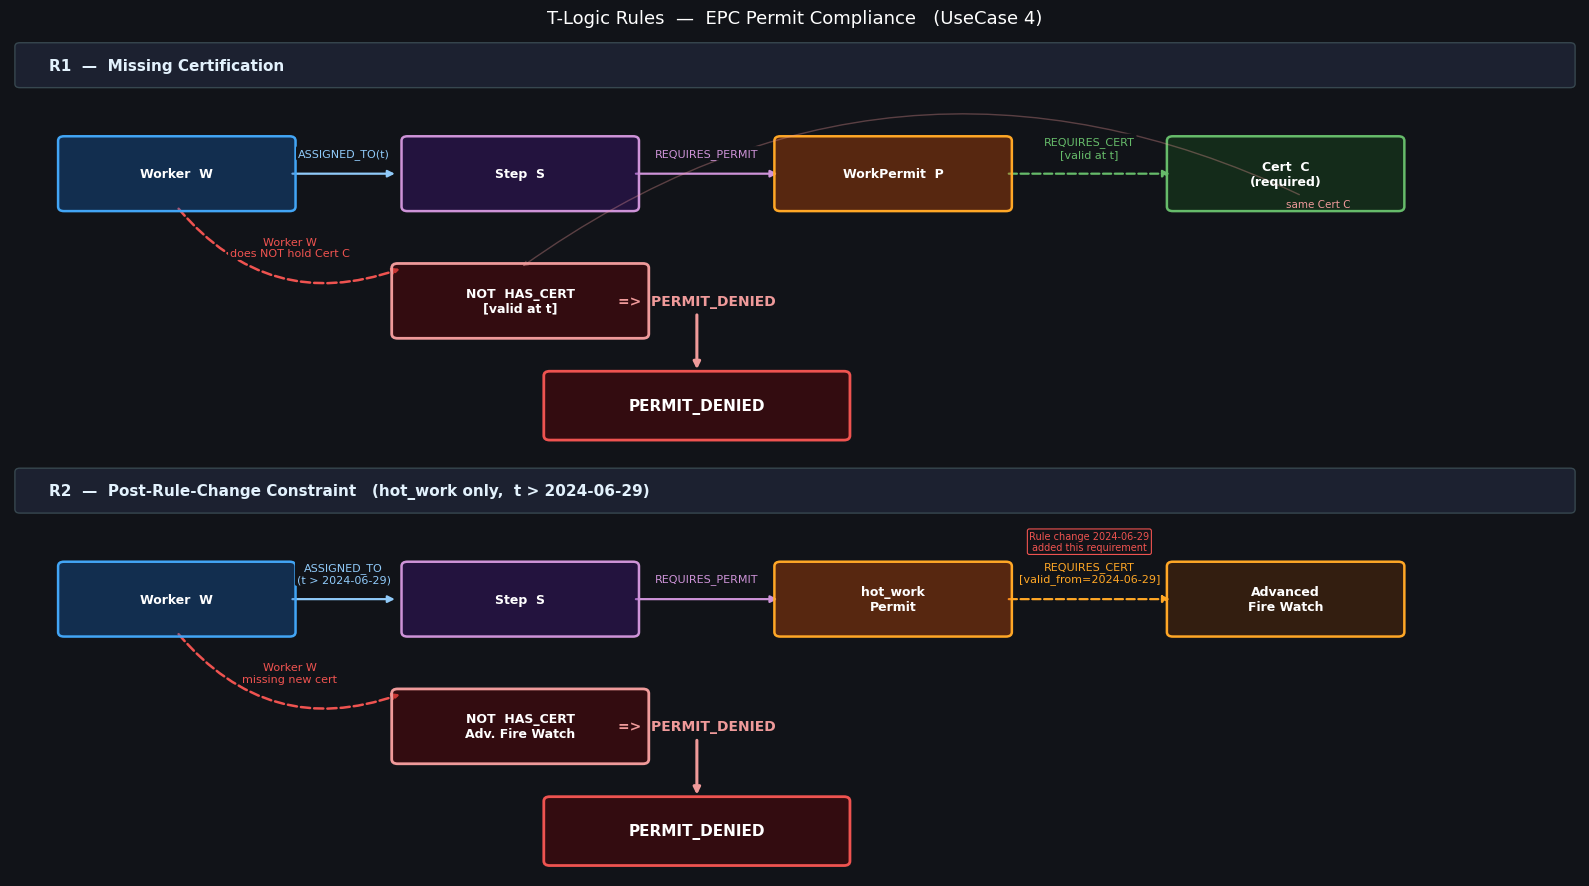

In [5]:
# FIG 4 — T-LOGIC RULES  (completely manual layout, two separate subplots)
# Each rule: top chain (body path) + bottom "NOT" condition + PERMIT_DENIED head
# ═════════════════════════════════════════════════════════════════════════════
fig4, (axR1, axR2) = plt.subplots(2, 1, figsize=(16, 9))
fig4.patch.set_facecolor(BG)

def rule_panel(ax, title, chain_nodes, chain_edges, neg_node, neg_label,
               neg_connect, conclusion_x=8.0):
    """
    chain_nodes : list of (cx, cy, label, fc, ec)
    chain_edges : list of (xi, yi, xj, yj, label, color, ls, rad)
    neg_node    : (cx, cy, label, fc, ec) — the negation/missing box
    neg_label   : text on the red dashed arrow
    neg_connect : (x1,y1,x2,y2) start/end of the red "NOT HAS" arc
    conclusion_x: x centre of the PERMIT_DENIED box
    """
    ax.set_xlim(0, 16); ax.set_ylim(0, 5.5)
    ax.axis("off"); ax.set_facecolor(BG)

    # Rule title strip
    ax.add_patch(FancyBboxPatch((0.1, 4.9), 15.8, 0.5,
                                boxstyle="round,pad=0.05", fc=CARD, ec="#37474F", lw=1))
    ax.text(0.4, 5.15, title, fontsize=11, fontweight="bold",
            color="#E3F2FD", va="center")

    # Chain nodes
    for (cx, cy, lbl, fc, ec) in chain_nodes:
        box(ax, cx, cy, 2.3, 0.88, lbl, fc, ec, fontsize=9)

    # Chain edges (body path)
    for (x1, y1, x2, y2, lbl, col, ls, rad) in chain_edges:
        arrow(ax, x1, y1, x2, y2, lbl, col, lw=1.6, ls=ls, rad=rad,
              label_offset=(0, 0.2), fontsize=8)

    # Negation / missing node
    cx, cy, lbl, fc, ec = neg_node
    box(ax, cx, cy, 2.5, 0.88, lbl, fc, ec, fontsize=9, lw=2.0)

    # Red "NOT HAS_CERT" arc from worker to negation box
    x1, y1, x2, y2 = neg_connect
    arrow(ax, x1, y1, x2, y2, neg_label, "#EF5350", lw=1.8,
          ls="--", rad=0.35, label_offset=(0, -0.28), fontsize=8)

    # Implication arrow
    ax.annotate("", xy=(conclusion_x, 1.05),
                xytext=(conclusion_x, 1.85),
                arrowprops=dict(arrowstyle="-|>", color="#EF9A9A", lw=2.2))
    ax.text(conclusion_x, 1.95, "=>  PERMIT_DENIED", ha="center",
            fontsize=10, color="#EF9A9A", fontweight="bold")

    # PERMIT_DENIED box
    box(ax, conclusion_x, 0.6, 3.0, 0.8, "PERMIT_DENIED",
        "#7A000055", "#EF5350", fontsize=11, lw=2.0)


# ── R1: MissingCert ──────────────────────────────────────────────────────────
# Layout:
#  TOP (y=3.7): [Worker W] -ASSIGNED-> [Step S] -REQ_PERMIT-> [WorkPermit P] -REQ_CERT-> [Cert C]
#  BOT (y=2.0): [NOT HAS Cert C]  <-- red dashed arc from Worker W
#
rule_panel(
    axR1,
    title="R1  —  Missing Certification",
    chain_nodes=[
        ( 1.7, 3.7, "Worker  W",        "#1565C055", "#42A5F5"),
        ( 5.2, 3.7, "Step  S",          "#4A148C55", "#CE93D8"),
        ( 9.0, 3.7, "WorkPermit  P",    "#E6510055", "#FFA726"),
        (13.0, 3.7, "Cert  C\n(required)", "#1B5E2055", "#66BB6A"),
    ],
    chain_edges=[
        (2.85, 3.7, 3.95, 3.7, "ASSIGNED_TO(t)",              "#90CAF9", "-",  0.0),
        (6.35, 3.7, 7.85, 3.7, "REQUIRES_PERMIT",             "#CE93D8", "-",  0.0),
        (10.15,3.7, 11.85,3.7, "REQUIRES_CERT\n[valid at t]", "#66BB6A", "--", 0.0),
    ],
    neg_node=(5.2, 2.0, "NOT  HAS_CERT\n[valid at t]", "#7A000055", "#EF9A9A"),
    neg_label="Worker W\ndoes NOT hold Cert C",
    neg_connect=(1.7, 3.26, 4.0, 2.44),
    conclusion_x=7.0,
)

# Annotation: same cert C
axR1.annotate("same Cert C", xy=(5.2, 2.44), xytext=(13.0, 3.26),
              fontsize=7.5, color="#EF9A9A",
              arrowprops=dict(arrowstyle="->", color="#EF9A9A55", lw=1,
                              connectionstyle="arc3,rad=0.3"))

# ── R2: PostRuleChange ───────────────────────────────────────────────────────
# Layout:
#  TOP (y=3.7): [Worker W] -ASSIGNED(t>RC)-> [Step S] -REQ_PERMIT-> [hot_work] -REQ_CERT(post)-> [Adv. FW]
#              Note on hot_work: "rule change 2024-06-29 added Adv. FW requirement"
#  BOT (y=2.0): [NOT HAS Adv. FW]  <-- red dashed arc from Worker W
#
rule_panel(
    axR2,
    title="R2  —  Post-Rule-Change Constraint   (hot_work only,  t > 2024-06-29)",
    chain_nodes=[
        ( 1.7, 3.7, "Worker  W",           "#1565C055", "#42A5F5"),
        ( 5.2, 3.7, "Step  S",             "#4A148C55", "#CE93D8"),
        ( 9.0, 3.7, "hot_work\nPermit",    "#E6510055", "#FFA726"),
        (13.0, 3.7, "Advanced\nFire Watch","#7A350055", "#FFA726"),
    ],
    chain_edges=[
        (2.85, 3.7, 3.95, 3.7, "ASSIGNED_TO\n(t > 2024-06-29)", "#90CAF9", "-",  0.0),
        (6.35, 3.7, 7.85, 3.7, "REQUIRES_PERMIT",               "#CE93D8", "-",  0.0),
        (10.15,3.7, 11.85,3.7, "REQUIRES_CERT\n[valid_from=2024-06-29]",
                                                                  "#FFA726", "--", 0.0),
    ],
    neg_node=(5.2, 2.0, "NOT  HAS_CERT\nAdv. Fire Watch", "#7A000055", "#EF9A9A"),
    neg_label="Worker W\nmissing new cert",
    neg_connect=(1.7, 3.26, 4.0, 2.44),
    conclusion_x=7.0,
)

# Rule-change annotation on the hot_work → Adv.FW edge
axR2.text(11.0, 4.35,
          "Rule change 2024-06-29\nadded this requirement",
          ha="center", fontsize=7, color="#EF5350",
          bbox=dict(boxstyle="round,pad=0.2", fc=BG, ec="#EF5350", lw=0.8))

fig4.suptitle("T-Logic Rules  —  EPC Permit Compliance   (UseCase 4)",
              color="white", fontsize=13)
fig4.tight_layout(h_pad=1.0)
fig4.savefig(OUT_DIR / "viz_tlogic_rules.png", dpi=160, bbox_inches="tight",
             facecolor=BG)
print("Saved viz_tlogic_rules.png")
print("\nAll done.")